# NB03 – Visualisierungen
### CAS Information Engineering – Scripting Project
**Gruppe:** SC26_Gruppe_2 | **Verantwortlich:** Person C | **Datum:** März 2026

---
Erstellt die Pflicht-Charts 1–5 (Charts 1–2 gemäss Aufgabenstellung).  
Liest aus `data/processed/` und `data/intermediate/`. Speichert in `output/charts/`.

---
| [← NB02 Daten Analyse](02_Daten_Analyse.ipynb) | [↑ Projektübersicht](00_Project_Overview.ipynb) | [→ NB04 Business Case](04_Business_Case.ipynb) |
|:---|:---:|---:|


In [29]:
# ── Imports ──────────────────────────────────────────────────────────────────
import os, warnings
import numpy  as np
import pandas as pd
import matplotlib.pyplot    as plt
import matplotlib.ticker    as mticker
import matplotlib.patches   as mpatches
from   matplotlib.colors    import Normalize
from   matplotlib            import cm
warnings.filterwarnings('ignore')

# ── config.json laden ───────────────────────────────────────────────────────
# Schalter NIE direkt hier setzen — immer in config.json anpassen.
import json as _json, datetime as _dt
with open('config.json') as _f: CFG = _json.load(_f)

# Aliases (nur lesend)
MODE          = CFG['mode']
LIFETIME      = CFG['pflicht']['wirtschaftlichkeit']['lifetime_j']
LIFETIME_LONG = CFG['pflicht']['langzeit']['lifetime_long_j']
SYMLOG_THRESH = CFG['visualisierung']['symlog_linthresh']
BASE_PEAK_GW  = CFG['szenarien']['ch_spitzenlast_gw']
print(f'config.json | MODE={MODE} | LIFETIME={LIFETIME}J | SYMLOG={SYMLOG_THRESH}')
DIR_RAW    = os.path.join(MODE, 'raw')           # ch_netzlast_raw.csv (Roh, von NB1)
DIR_PROC   = os.path.join(MODE, 'processed')     # ch_spot_prices_clean.csv (von NB2)
DIR_INTER    = os.path.join(MODE, 'intermediate')        # szenario-unabhängig (spread etc.)
SZ_AKTIV     = CFG['szenarien']['gleichzeitigkeit_aktiv']
DIR_INTER_SZ = os.path.join(DIR_INTER, SZ_AKTIV)          # wirtschaftlichkeit.csv, szenarien.csv
CHARTS_DIR = os.path.join('output', 'charts', SZ_AKTIV)
os.makedirs(CHARTS_DIR, exist_ok=True)

# Farbpalette
C_PRIV  = '#42A5F5'
C_GEW   = '#66BB6A'
C_IND   = '#FFA726'
C_UTIL  = '#EF5350'
C_PRICE = '#FF6F00'
C_LOAD  = '#4CAF50'
SEG_COLORS = [C_PRIV, C_GEW, C_IND, C_UTIL]

# Daten laden
df_prices = pd.read_csv(os.path.join(DIR_PROC,  'ch_spot_prices_clean.csv'),
                        parse_dates=['timestamp'])
df_econ   = pd.read_csv(os.path.join(DIR_INTER_SZ, 'wirtschaftlichkeit.csv'))
df_sc     = pd.read_csv(os.path.join(DIR_INTER_SZ, 'netzentlastung_szenarien.csv'))
df_load   = pd.read_csv(os.path.join(DIR_RAW,   'ch_netzlast_raw.csv'),
                        parse_dates=['timestamp'])

# ── FIX 1: rev_per_kwh berechnen falls in CSV nicht vorhanden ────────────────
if 'rev_per_kwh' not in df_econ.columns:
    CAP_MAP = {'Privat_10kWh': 10, 'Gewerbe_100kWh': 100,
               'Industrie_1MWh': 1000, 'Utility_10MWh': 10000}
    df_econ['rev_per_kwh'] = df_econ.apply(
        lambda r: (r['annual_rev'] * 2) / CAP_MAP.get(r['segment'], 100), axis=1)
    print('rev_per_kwh berechnet')

# ── FIX 2: Spalten-Aliases (NB2 speichert 'roi_pct', Chart 1 erwartet 'roi') ─
if 'roi_pct'       in df_econ.columns and 'roi'     not in df_econ.columns:
    df_econ['roi']     = df_econ['roi_pct']
if 'payback_years'  in df_econ.columns and 'payback' not in df_econ.columns:
    df_econ['payback'] = df_econ['payback_years']

# ── FIX 3: Zeitfeatures sicherstellen (.dt.hour statt .hour auf Series) ──────
df_prices['timestamp'] = pd.to_datetime(df_prices['timestamp'], utc=True)
if 'hour'  not in df_prices.columns:
    df_prices['hour']  = df_prices['timestamp'].dt.hour
if 'month' not in df_prices.columns:
    df_prices['month'] = df_prices['timestamp'].dt.month
df_load['timestamp'] = pd.to_datetime(df_load['timestamp'], utc=True)

print(f'MODE       : {MODE}')
print(f'df_prices  : {len(df_prices):,} Zeilen  <- {DIR_PROC}/ch_spot_prices_clean.csv')
print(f'df_load    : {len(df_load):,} Zeilen  <- {DIR_RAW}/ch_netzlast_raw.csv')
print(f'df_econ    : {len(df_econ)} Segmente <- {DIR_INTER_SZ}/wirtschaftlichkeit.csv')
print(f'df_sc      : {len(df_sc)} Szenarien <- {DIR_INTER_SZ}/netzentlastung_szenarien.csv')
print(f'df_econ Spalten: {list(df_econ.columns)}')
print('Daten geladen. Erstelle Visualisierungen...')


config.json | MODE=data | LIFETIME=12J | SYMLOG=10000
MODE       : data
df_prices  : 28,392 Zeilen  <- data\processed/ch_spot_prices_clean.csv
df_load    : 28,348 Zeilen  <- data\raw/ch_netzlast_raw.csv
df_econ    : 4 Segmente <- data\intermediate\realistisch/wirtschaftlichkeit.csv
df_sc      : 4 Szenarien <- data\intermediate\realistisch/netzentlastung_szenarien.csv
df_econ Spalten: ['segment', 'capex', 'annual_rev', 'opex_annual', 'net_annual', 'payback_years', 'roi_pct', 'rev_per_kwh', 'roi', 'payback']
Daten geladen. Erstelle Visualisierungen...


In [30]:
# ── Verifikation: Eingabedaten ───────────────────────────────────────────────
print(f'Preise  : {df_prices.shape} | Last: {df_load.shape}')
print(f'Econ    : {df_econ.shape}   | Szenarien: {df_sc.shape}')
df_econ[['segment','capex','roi_pct','payback_years']].head()


Preise  : (28392, 6) | Last: (28348, 2)
Econ    : (4, 10)   | Szenarien: (4, 9)


,segment,capex,roi_pct,payback_years
0,Privat_10kWh,4000,0.565788,176.744782
1,Gewerbe_100kWh,30000,1.409336,70.955397
2,Industrie_1MWh,220000,2.310445,43.281707
3,Utility_10MWh,1800000,1.292755,77.354205


**Setup.** `DIR_PROC` = `processed/` (Zeitreihen), `DIR_INTER` = `intermediate/` (Simulationsergebnisse), `DIR_RAW` = `raw/` (Netzlast-Rohdaten).
Spalten-Aliases (`roi_pct→roi`, `payback_years→payback`) stellen Kompatibilität unabhängig vom Datenherkunft-Modus sicher.

---
## Chart 1 (Aufgabe a): Summary-Diagramm – Wirtschaftlichkeit

*Fasst die Ergebnisse der Analyse zusammen und weckt das Interesse des Publikums.*


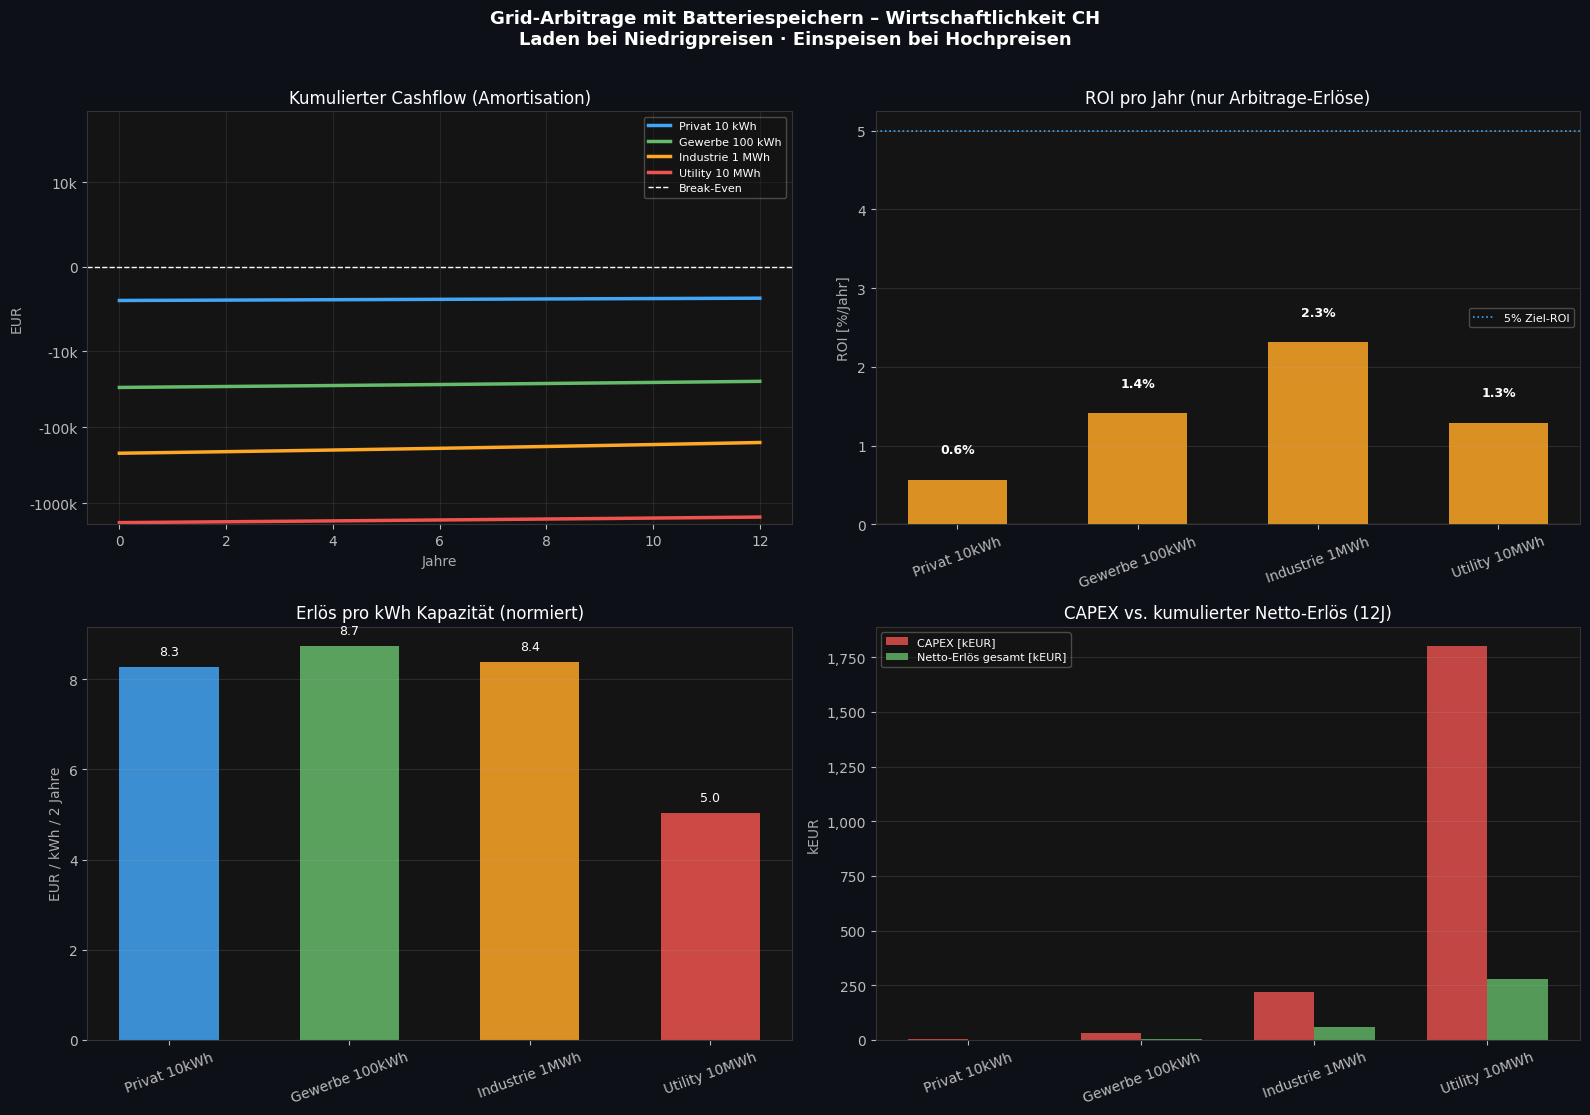

✅ Chart 1 gespeichert: output\charts\realistisch\chart1_wirtschaftlichkeit_summary.png


In [31]:
# ── Chart 1: Wirtschaftlichkeit-Summary (4 Panels) ──────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.patch.set_facecolor('#0d1117')
for ax in axes.flat:
    ax.set_facecolor('#141414')
    ax.tick_params(colors='#bbbbbb')
    for sp in ax.spines.values(): sp.set_edgecolor('#333333')

fig.suptitle('Grid-Arbitrage mit Batteriespeichern – Wirtschaftlichkeit CH\n'
             'Laden bei Niedrigpreisen · Einspeisen bei Hochpreisen',
             color='white', fontsize=13, fontweight='bold', y=1.01)

seg_names = df_econ['segment'].str.replace('_', ' ').tolist()

# --- Panel 1: Kumulierter Cashflow (Amortisationskurven) ---
ax = axes[0, 0]
LIFETIME = 12
years = np.arange(0, LIFETIME + 1)
for row, color in zip(df_econ.itertuples(), SEG_COLORS):
    net = row.net_annual
    cf  = [-row.capex + net * y for y in years]
    lbl = row.segment.replace('_',' ').replace('kWh',' kWh').replace('MWh',' MWh')
    ax.plot(years, cf, color=color, lw=2.5, label=lbl)
    # Break-Even annotieren (falls innerhalb 30 Jahre)
    if net > 0:
        be_yr = row.capex / net
        if be_yr <= 30:
            ax.annotate(f'{be_yr:.1f}J',
                        xy=(min(be_yr, LIFETIME), 0),
                        xytext=(min(be_yr, LIFETIME) + 0.3, row.capex * 0.05),
                        color=color, fontsize=7,
                        arrowprops=dict(arrowstyle='->', color=color, lw=0.8))
ax.axhline(0, color='white', lw=1, linestyle='--', label='Break-Even')
ax.set_title('Kumulierter Cashflow (Amortisation)', color='white')
ax.set_xlabel('Jahre', color='#aaaaaa')
ax.set_ylabel('EUR', color='#aaaaaa')
# Symlog: alle Segmente sichtbar trotz 100x CAPEX-Unterschied
ax.set_yscale('symlog', linthresh=10000)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v,_: f'{v/1000:.0f}k' if abs(v) >= 1000 else f'{v:.0f}'))
ax.legend(fontsize=8, framealpha=0.3, facecolor='#111', labelcolor='white')
ax.grid(True, alpha=0.12)

# --- Panel 2: ROI pro Jahr Vergleich ---
ax = axes[0, 1]
roi_vals = df_econ['roi'].values
roi_colors = ['#EF5350' if v < 0 else '#66BB6A' if v > 5 else '#FFA726' for v in roi_vals]
bars = ax.bar(seg_names, roi_vals, color=roi_colors, alpha=0.85, width=0.55)
ax.axhline(0, color='white', lw=0.8)
ax.axhline(5, color='#42A5F5', lw=1.2, linestyle=':', label='5% Ziel-ROI')
for bar, val in zip(bars, roi_vals):
    ypos = val + 0.3 if val >= 0 else val - 0.8
    ax.text(bar.get_x() + bar.get_width()/2, ypos, f'{val:.1f}%',
            ha='center', va='bottom', color='white', fontsize=9, fontweight='bold')
ax.set_title('ROI pro Jahr (nur Arbitrage-Erlöse)', color='white')
ax.set_ylabel('ROI [%/Jahr]', color='#aaaaaa')
ax.tick_params(axis='x', rotation=20)
ax.legend(fontsize=8, framealpha=0.3, facecolor='#111', labelcolor='white')
ax.grid(True, axis='y', alpha=0.15)

# --- Panel 3: Erlös pro kWh normiert ---
ax = axes[1, 0]
rev_kwh = df_econ['rev_per_kwh'].values
bars2 = ax.bar(seg_names, rev_kwh, color=SEG_COLORS, alpha=0.85, width=0.55)
for bar, val in zip(bars2, rev_kwh):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.1f}', ha='center', va='bottom', color='white', fontsize=9)
ax.set_title('Erlös pro kWh Kapazität (normiert)', color='white')
ax.set_ylabel('EUR / kWh / 2 Jahre', color='#aaaaaa')
ax.tick_params(axis='x', rotation=20)
ax.grid(True, axis='y', alpha=0.15)

# --- Panel 4: CAPEX vs. kumulierter Netto-Erlös ---
ax = axes[1, 1]
x = np.arange(len(seg_names))
w = 0.35
capex_vals  = df_econ['capex'].values / 1000  # → kEUR
net_total   = (df_econ['net_annual'] * LIFETIME).values / 1000
ax.bar(x - w/2, capex_vals,  w, label='CAPEX [kEUR]',    color='#EF5350', alpha=0.8)
ax.bar(x + w/2, net_total,   w, label='Netto-Erlös gesamt [kEUR]', color='#66BB6A', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(seg_names, rotation=20)
ax.set_title(f'CAPEX vs. kumulierter Netto-Erlös ({LIFETIME}J)', color='white')
ax.set_ylabel('kEUR', color='#aaaaaa')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:,.0f}'))
ax.legend(fontsize=8, framealpha=0.3, facecolor='#111', labelcolor='white')
ax.grid(True, axis='y', alpha=0.15)

plt.tight_layout()
chart1_path = os.path.join(CHARTS_DIR, 'chart1_wirtschaftlichkeit_summary.png')
plt.savefig(chart1_path, dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f'✅ Chart 1 gespeichert: {chart1_path}')


**Einzelplots** (für Bericht-Einbettung):

In [32]:
# ── Chart 1: Einzelplots ─────────────────────────────────────────────────────
# Jedes der 4 Panels als eigenständiges Bild (grösser, für Bericht)
PANEL_DEFS = [
    ('chart1a_amortisation.png',     'Kumulierter Cashflow (Amortisation)',
     'Zeitraum [Jahre]', 'EUR'),
    ('chart1b_roi.png',              'ROI pro Jahr (nur Arbitrage-Erlöse)',
     'Segment', 'ROI [%/Jahr]'),
    ('chart1c_erloese_kwh.png',      'Erlös pro kWh Kapazität (normiert)',
     'Segment', 'EUR / kWh / 2 Jahre'),
    ('chart1d_capex_ertrag.png',     f'CAPEX vs. kumulierter Netto-Erlös ({LIFETIME}J)',
     'Segment', 'kEUR'),
]

for (filename, title, xlabel, ylabel), ax_src in zip(PANEL_DEFS, axes.flat):
    fig_s, ax_s = plt.subplots(figsize=(10, 6))
    fig_s.patch.set_facecolor('#0d1117')
    ax_s.set_facecolor('#141414')
    ax_s.tick_params(colors='#bbbbbb')
    for sp in ax_s.spines.values(): sp.set_edgecolor('#333333')

    # Inhalte neu zeichnen (aus df_econ — gleiche Daten wie Komposit)
    if 'Amortisation' in title:
        years_x = np.arange(0, LIFETIME + 1)
        for row, color in zip(df_econ.itertuples(), SEG_COLORS):
            cf = [-row.net_annual * 0 + (-row.capex + row.net_annual * y) for y in years_x]
            lbl = row.segment.replace('_',' ').replace('kWh',' kWh').replace('MWh',' MWh')
            ax_s.plot(years_x, cf, color=color, lw=2.5, label=lbl)
            if row.net_annual > 0:
                be = row.capex / row.net_annual
                if be <= LIFETIME + 5:
                    ax_s.annotate(f'{be:.1f}J', xy=(min(be, LIFETIME), 0),
                        xytext=(min(be, LIFETIME)+0.3, row.capex*0.05),
                        color=color, fontsize=8,
                        arrowprops=dict(arrowstyle='->', color=color, lw=0.8))
        ax_s.axhline(0, color='white', lw=1, linestyle='--', label='Break-Even')
        # Symlog: alle Segmente sichtbar trotz 100x CAPEX-Unterschied
        ax_s.set_yscale('symlog', linthresh=10000)
        ax_s.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda v,_: f'{v/1000:.0f}k' if abs(v) >= 1000 else f'{v:.0f}'))
        ax_s.set_xlabel('Jahre', color='#aaa')

    elif 'ROI' in title:
        roi_vals = df_econ['roi_pct'].values
        bars = ax_s.bar(seg_names, roi_vals, color=SEG_COLORS, alpha=0.85)
        ax_s.axhline(5, color='#42A5F5', lw=1.5, linestyle=':', label='5% Ziel-ROI')
        for bar, val in zip(bars, roi_vals):
            ax_s.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.15,
                      f'{val:.1f}%', ha='center', color='white', fontsize=10, fontweight='bold')
        ax_s.set_ylabel('ROI [%/Jahr]', color='#aaa')

    elif 'Erlös' in title:
        rev_vals = df_econ['rev_per_kwh'].values
        bars = ax_s.bar(seg_names, rev_vals, color=SEG_COLORS, alpha=0.85)
        for bar, val in zip(bars, rev_vals):
            ax_s.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                      f'{val:.1f}', ha='center', color='white', fontsize=10)
        ax_s.set_ylabel('EUR / kWh / 2J', color='#aaa')

    else:  # CAPEX vs Ertrag
        x = np.arange(len(seg_names)); w = 0.35
        capex_v = df_econ['capex'].values / 1000
        net_v   = (df_econ['net_annual'] * LIFETIME).values / 1000
        ax_s.bar(x - w/2, capex_v, w, label='CAPEX [kEUR]', color='#EF5350', alpha=0.8)
        ax_s.bar(x + w/2, net_v,   w, label='Netto-Erlös [kEUR]', color='#66BB6A', alpha=0.8)
        ax_s.set_xticks(x); ax_s.set_xticklabels(seg_names, rotation=15, ha='right')
        ax_s.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:,.0f}'))

    ax_s.set_title(title, color='white', fontsize=13, fontweight='bold')
    ax_s.grid(True, alpha=0.12)
    ax_s.legend(fontsize=9, framealpha=0.3, facecolor='#111', labelcolor='white')
    plt.tight_layout()
    p = os.path.join(CHARTS_DIR, filename)
    plt.savefig(p, dpi=150, bbox_inches='tight', facecolor='#0d1117')
    plt.close()
    print(f'  Einzelplot: {filename}')


  Einzelplot: chart1a_amortisation.png
  Einzelplot: chart1b_roi.png
  Einzelplot: chart1c_erloese_kwh.png
  Einzelplot: chart1d_capex_ertrag.png


**Langzeit-Chart (20 Jahre):**  
Zeigt den kumulierten Cashflow bis Jahr 20 inkl. Marker für Jahr 12 (Ende Simulationszeitraum) und den Break-Even. Für das Utility-Segment wird die Wachstumsdynamik nach Break-Even sichtbar; für Privat wird der Break-Even bei ~18 Jahren quantifiziert.


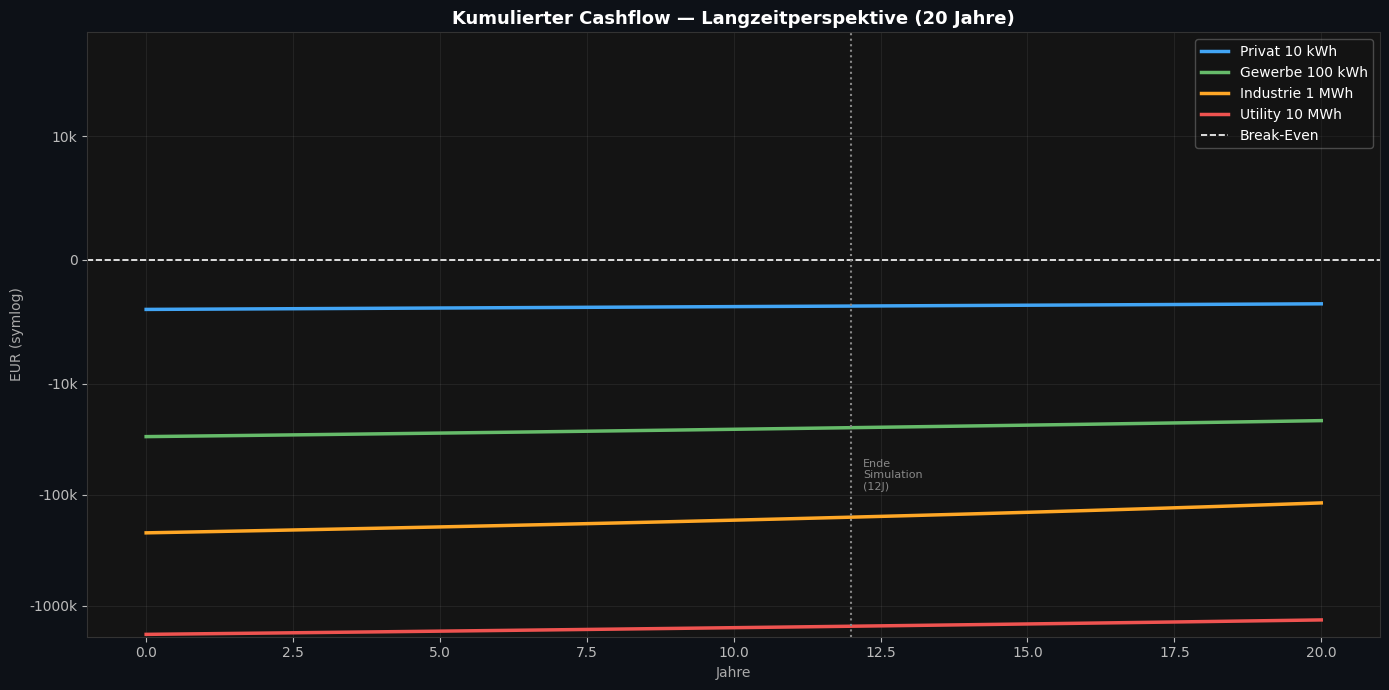

chart1e_langzeit.png gespeichert


In [33]:
# ── Chart 1e: Langzeit-Amortisation (20 Jahre) ───────────────────────────────
# Zeigt alle Segmente bis Jahr 20, Marker bei Jahr 12 und Break-Even
LIFETIME_LONG = 20

fig5, ax5 = plt.subplots(figsize=(14, 7))
fig5.patch.set_facecolor('#0d1117')
ax5.set_facecolor('#141414')
ax5.tick_params(colors='#bbbbbb')
for sp in ax5.spines.values(): sp.set_edgecolor('#333333')

years_long = np.arange(0, LIFETIME_LONG + 1)
for row, color in zip(df_econ.itertuples(), SEG_COLORS):
    cf = [-row.capex + row.net_annual * y for y in years_long]
    lbl = row.segment.replace('_',' ').replace('kWh',' kWh').replace('MWh',' MWh')
    ax5.plot(years_long, cf, color=color, lw=2.5, label=lbl)
    if row.net_annual > 0:
        be = row.capex / row.net_annual
        if be <= LIFETIME_LONG + 2:
            ax5.annotate(f'{be:.1f}J',
                         xy=(min(be, LIFETIME_LONG), 0),
                         xytext=(min(be, LIFETIME_LONG) + 0.4, row.capex * 0.04),
                         color=color, fontsize=9, fontweight='bold',
                         arrowprops=dict(arrowstyle='->', color=color, lw=1.0))

# Break-Even Linie
ax5.axhline(0, color='white', lw=1.2, linestyle='--', label='Break-Even', zorder=2)

# Marker bei Jahr 12 (Ende Simulationszeitraum)
ax5.axvline(12, color='#888888', lw=1.5, linestyle=':', zorder=2)
ax5.text(12.2, ax5.get_ylim()[0] * 0.05 if ax5.get_ylim()[0] < 0 else ax5.get_ylim()[1] * 0.05,
         'Ende\nSimulation\n(12J)',
         color='#888888', fontsize=8, va='bottom')

# Symlog
ax5.set_yscale('symlog', linthresh=10000)
ax5.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v,_: f'{v/1000:.0f}k' if abs(v) >= 1000 else f'{v:.0f}'))

ax5.set_title('Kumulierter Cashflow — Langzeitperspektive (20 Jahre)',
              color='white', fontsize=13, fontweight='bold')
ax5.set_xlabel('Jahre', color='#aaa')
ax5.set_ylabel('EUR (symlog)', color='#aaa')
ax5.legend(fontsize=10, framealpha=0.3, facecolor='#111', labelcolor='white')
ax5.grid(True, alpha=0.10)

plt.tight_layout()
p5 = os.path.join(CHARTS_DIR, 'chart1e_langzeit.png')
plt.savefig(p5, dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
plt.close()
print(f'chart1e_langzeit.png gespeichert')


**Chart 1 — 4 Panels:**
- **Amortisation:** kumulierter Cashflow, Break-Even annotiert
- **ROI/Jahr:** direkter Vergleich mit 5%-Ziel-Linie
- **Erlös/kWh:** kapazitätsnormiert für Segmentvergleich
- **CAPEX vs. Netto-Erlös:** Investitionshöhe vs. 12-Jahres-Ertrag

---
## Chart 2 (Aufgabe b): Heatmap – Spot-Preis nach Stunde × Monat

*Karte/Heatmap gemäss Aufgabe b) – zeigt die zeitliche Preisstruktur als 2D-Heatmap.*  
Die Heatmap ist das zentrale Instrument zur Identifikation der optimalen Lade- und Einspeisezeitfenster.


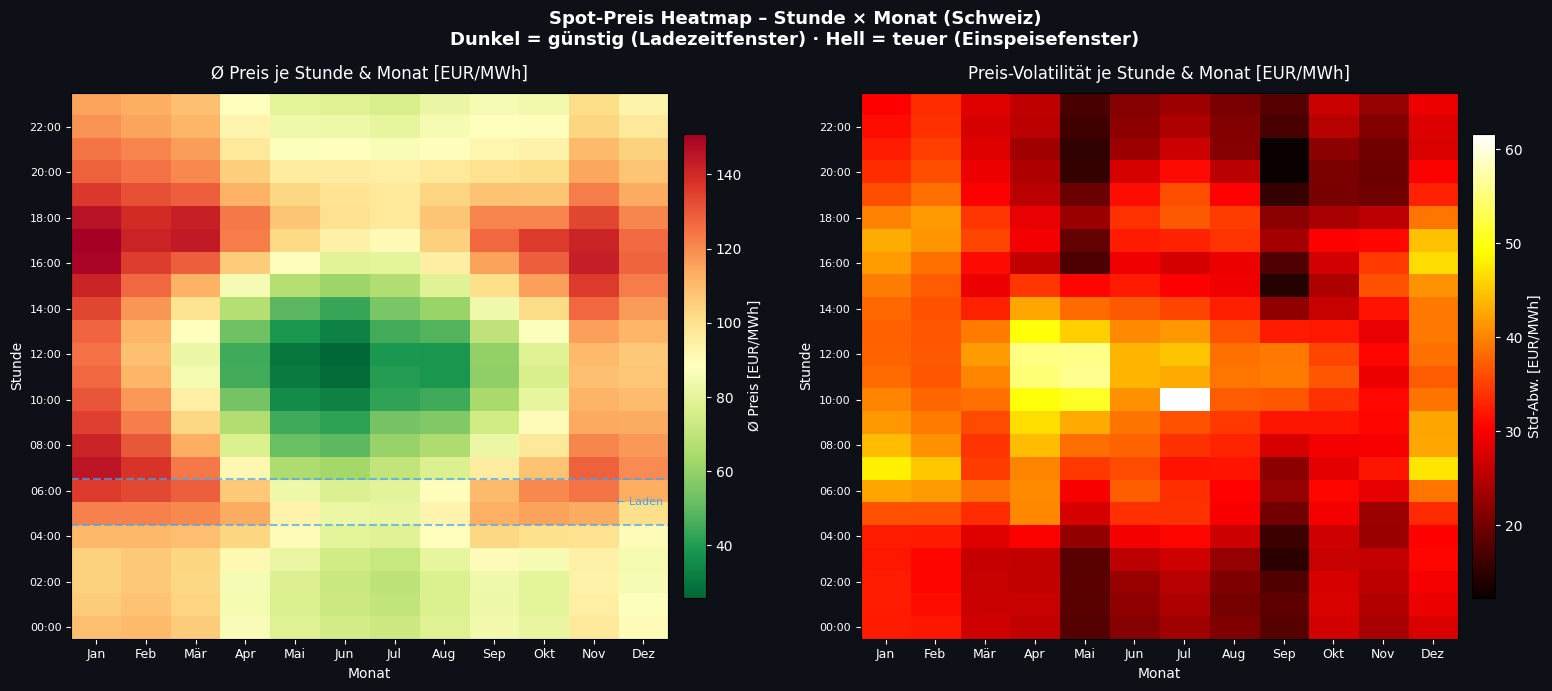

✅ Chart 2 gespeichert: output\charts\realistisch\chart2_heatmap_stunde_monat.png


In [34]:
# ── Chart 2: Heatmap Stunde × Monat (Aufgabe b) ─────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0d1117')
for ax in axes:
    ax.set_facecolor('#0d1117')
    ax.tick_params(colors='white')

fig.suptitle('Spot-Preis Heatmap – Stunde × Monat (Schweiz)\n'
             'Dunkel = günstig (Ladezeitfenster) · Hell = teuer (Einspeisefenster)',
             color='white', fontsize=13, fontweight='bold')

# Pivot-Tabelle: Mittelwert pro Stunde × Monat
pivot = df_prices.pivot_table(
    index='hour', columns='month', values='price_eur_mwh', aggfunc='mean')

month_labels = ['Jan','Feb','Mär','Apr','Mai','Jun','Jul','Aug','Sep','Okt','Nov','Dez']

# --- Panel 1: Heatmap Mittelwert ---
ax = axes[0]
im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn_r',
               origin='lower', vmin=pivot.values.min(), vmax=pivot.values.max())
cbar = plt.colorbar(im, ax=ax, label='Ø Preis [EUR/MWh]', shrink=0.85, pad=0.02)
cbar.ax.yaxis.label.set_color('white')
cbar.ax.tick_params(colors='white')

ax.set_xticks(range(12))
ax.set_xticklabels(month_labels, fontsize=9, color='white')
ax.set_yticks(range(24)[::2])
ax.set_yticklabels([f'{h:02d}:00' for h in range(24)[::2]], fontsize=8, color='white')
ax.set_title('Ø Preis je Stunde & Monat [EUR/MWh]', color='white', pad=10)
ax.set_xlabel('Monat', color='white')
ax.set_ylabel('Stunde', color='white')

# Günstigste Zone markieren (Laden)
ax.axhline(y=4.5, color='#42A5F5', lw=1.5, linestyle='--', alpha=0.7)
ax.axhline(y=6.5, color='#42A5F5', lw=1.5, linestyle='--', alpha=0.7)
ax.text(11.4, 5.5, '← Laden', color='#42A5F5', fontsize=8, ha='right', va='center')

# --- Panel 2: Heatmap Volatilität (Std) ---
pivot_std = df_prices.pivot_table(
    index='hour', columns='month', values='price_eur_mwh', aggfunc='std')

ax2 = axes[1]
im2 = ax2.imshow(pivot_std.values, aspect='auto', cmap='hot',
                  origin='lower')
cbar2 = plt.colorbar(im2, ax=ax2, label='Std-Abw. [EUR/MWh]', shrink=0.85, pad=0.02)
cbar2.ax.yaxis.label.set_color('white')
cbar2.ax.tick_params(colors='white')

ax2.set_xticks(range(12))
ax2.set_xticklabels(month_labels, fontsize=9, color='white')
ax2.set_yticks(range(24)[::2])
ax2.set_yticklabels([f'{h:02d}:00' for h in range(24)[::2]], fontsize=8, color='white')
ax2.set_title('Preis-Volatilität je Stunde & Monat [EUR/MWh]', color='white', pad=10)
ax2.set_xlabel('Monat', color='white')
ax2.set_ylabel('Stunde', color='white')

plt.tight_layout()
chart2_path = os.path.join(CHARTS_DIR, 'chart2_heatmap_stunde_monat.png')
plt.savefig(chart2_path, dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f'✅ Chart 2 gespeichert: {chart2_path}')


**Einzelplot** (Preis-Heatmap):

In [35]:
# ── Chart 2: Einzelplots beider Panels ──────────────────────────────────────
# Panel A: Preis-Heatmap | Panel B: Volatilitäts-Heatmap — je eigenständig

pivot_mean = df_prices.pivot_table(index='hour', columns='month',
                                    values='price_eur_mwh', aggfunc='mean')
pivot_std  = df_prices.pivot_table(index='hour', columns='month',
                                    values='price_eur_mwh', aggfunc='std')
month_lbls = ['Jan','Feb','Mär','Apr','Mai','Jun','Jul','Aug','Sep','Okt','Nov','Dez']

for pivot, cmap, fname, title, ctitle in [
    (pivot_mean, 'RdYlGn_r', 'chart2a_heatmap_preis.png',
     'Ø Spot-Preis je Stunde & Monat [EUR/MWh]\nDunkel = günstig (Laden) · Hell = teuer (Einspeisen)',
     'Ø Preis [EUR/MWh]'),
    (pivot_std,  'hot_r',    'chart2b_heatmap_volatilitaet.png',
     'Preis-Volatilität je Stunde & Monat [EUR/MWh]\nHell = hohe Volatilität (beste Spread-Chancen)',
     'Std-Abw. [EUR/MWh]'),
]:
    fig2, ax2 = plt.subplots(figsize=(10, 8))
    fig2.patch.set_facecolor('#0d1117')
    ax2.set_facecolor('#141414'); ax2.tick_params(colors='#bbbbbb')
    for sp in ax2.spines.values(): sp.set_edgecolor('#333')
    im = ax2.imshow(pivot.values, cmap=cmap, aspect='auto',
                    vmin=pivot.values.min(), vmax=pivot.values.max())
    cb = plt.colorbar(im, ax=ax2); cb.ax.tick_params(colors='white')
    cb.set_label(ctitle, color='white')
    ax2.set_xticks(range(12)); ax2.set_xticklabels(month_lbls, color='white')
    ax2.set_yticks(range(0,24,2))
    ax2.set_yticklabels([f'{h:02d}:00' for h in range(0,24,2)], color='white')
    ax2.set_title(title, color='white', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Monat', color='#aaa'); ax2.set_ylabel('Stunde', color='#aaa')
    plt.tight_layout()
    p = os.path.join(CHARTS_DIR, fname)
    plt.savefig(p, dpi=150, bbox_inches='tight', facecolor='#0d1117')
    plt.close()
    print(f'  Einzelplot: {fname}')


  Einzelplot: chart2a_heatmap_preis.png
  Einzelplot: chart2b_heatmap_volatilitaet.png


**Chart 2 (Heatmap) — Pflichtaufgabe b.**
Links: Ø Preis je Stunde×Monat — Solar-Mittagstief (grün) und Winter-Abend-Spitzen (dunkelrot) erkennbar.
Rechts: Preis-Volatilität — hohe Volatilität = grösseres Arbitrage-Potenzial.

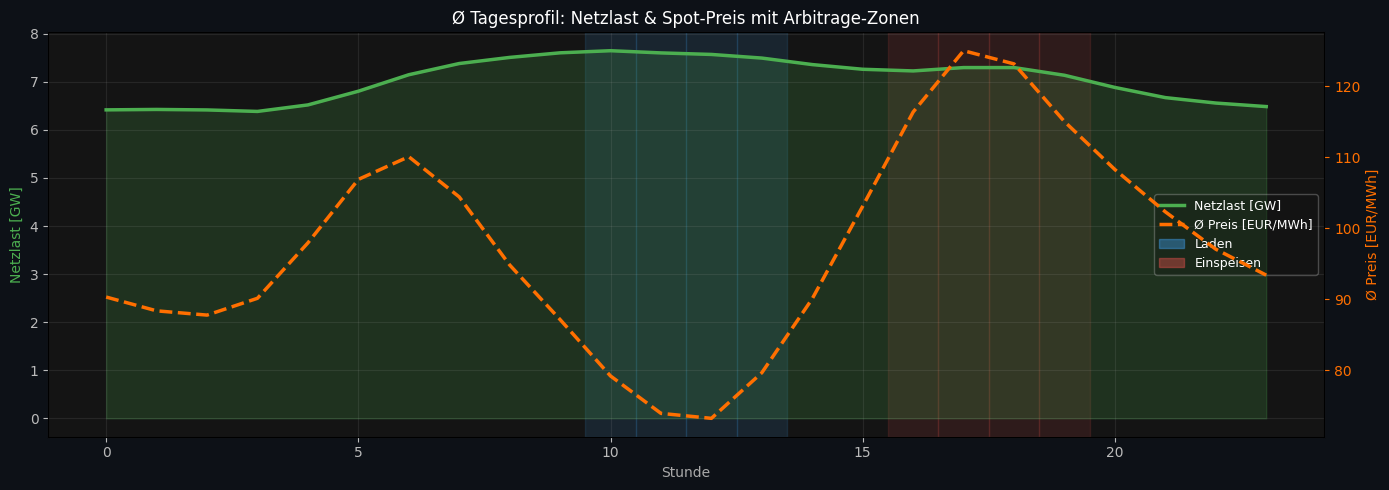

✅ Chart 3 gespeichert.


In [36]:
# ── Chart 3: Tagesprofil Netzlast & Preis ────────────────────────────────────

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#141414')
for sp in ax.spines.values():
    sp.set_edgecolor('#333333')

ax2 = ax.twinx()

# Stundenmittelwerte berechnen
# .dt.hour statt .hour weil der Index ein DatetimeIndex ist, keine Spalte
load_avg = df_load.copy()
load_avg['hour'] = load_avg['timestamp'].dt.hour
load_by_h  = load_avg.groupby('hour')['load_gw'].mean()
price_by_h = df_prices.groupby('hour')['price_eur_mwh'].mean()

ax.fill_between(load_by_h.index, load_by_h.values, alpha=0.2, color=C_LOAD)
ax.plot(load_by_h.index,   load_by_h.values,   color=C_LOAD,  lw=2.5, label='Netzlast [GW]')
ax2.plot(price_by_h.index, price_by_h.values,  color=C_PRICE, lw=2.5,
         linestyle='--', label='Ø Preis [EUR/MWh]')

# Günstigste und teuerste Stunden markieren
low_h  = price_by_h.nsmallest(4).index
high_h = price_by_h.nlargest(4).index
for h_val in low_h:
    ax.axvspan(h_val - 0.5, h_val + 0.5, alpha=0.12, color='#42A5F5', zorder=0)
for h_val in high_h:
    ax.axvspan(h_val - 0.5, h_val + 0.5, alpha=0.12, color='#EF5350', zorder=0)

ax.set_title('Ø Tagesprofil: Netzlast & Spot-Preis mit Arbitrage-Zonen',
             color='white', fontsize=12)
ax.set_xlabel('Stunde', color='#aaaaaa')
ax.set_ylabel('Netzlast [GW]', color=C_LOAD)
ax2.set_ylabel('Ø Preis [EUR/MWh]', color=C_PRICE)
ax.tick_params(colors='#bbbbbb')
ax2.tick_params(colors=C_PRICE)

p_blau = mpatches.Patch(color='#42A5F5', alpha=0.4, label='Ladezeitfenster (günstig)')
p_rot  = mpatches.Patch(color='#EF5350', alpha=0.4, label='Einspeisefenster (teuer)')
l1, n1 = ax.get_legend_handles_labels()
l2, n2 = ax2.get_legend_handles_labels()
ax.legend(l1 + l2 + [p_blau, p_rot], n1 + n2 + ['Laden', 'Einspeisen'],
          fontsize=9, framealpha=0.3, facecolor='#111', labelcolor='white')
ax.grid(True, alpha=0.12)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'chart3_tagesprofil.png'),
            dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('✅ Chart 3 gespeichert.')


**Einzelplot** (grösseres Format):

In [37]:
# ── Chart 3: Einzelplot ───────────────────────────────────────────────────────
# Chart 3 ist bereits ein einzelner Chart → gleiche Logik wie Komposit, nur grösser
# KORREKTUR: Zonen-Logik wie im Komposit (nsmallest/nlargest 4 Stunden)
# Bug zuvor: p25.quantile(0.25) = doppelter Quantil → fast keine Stunden qualifiziert
fig3, ax3 = plt.subplots(figsize=(14, 6))
fig3.patch.set_facecolor('#0d1117')
ax3.set_facecolor('#141414'); ax3.tick_params(colors='#bbbbbb')
for sp in ax3.spines.values(): sp.set_edgecolor('#333333')
ax3b = ax3.twinx()
ax3b.tick_params(colors=C_PRICE)

h_load  = df_load.groupby(df_load['timestamp'].dt.hour)['load_gw'].mean()
h_price = df_prices.groupby('hour')['price_eur_mwh'].mean()

# Arbitrage-Zonen: 4 günstigste und 4 teuerste Stunden (identisch mit Komposit)
low_h  = h_price.nsmallest(4).index
high_h = h_price.nlargest(4).index
for h_val in low_h:
    ax3.axvspan(h_val - 0.5, h_val + 0.5, alpha=0.18, color='#1565C0', zorder=0)
for h_val in high_h:
    ax3.axvspan(h_val - 0.5, h_val + 0.5, alpha=0.18, color='#B71C1C', zorder=0)

ax3.fill_between(h_load.index, h_load.values, alpha=0.15, color=C_LOAD)
ax3.plot(h_load.index, h_load.values, color=C_LOAD, lw=2.5, label='Netzlast [GW]')
ax3b.plot(h_price.index, h_price.values, color=C_PRICE, lw=2.5,
          linestyle='--', label='Ø Preis [EUR/MWh]')
ax3.set_xlabel('Stunde', color='#aaa')
ax3.set_ylabel('Netzlast [GW]', color=C_LOAD)
ax3b.set_ylabel('Ø Preis [EUR/MWh]', color=C_PRICE)
ax3.set_title('Ø Tagesprofil: Netzlast & Spot-Preis mit Arbitrage-Zonen',
              color='white', fontsize=13, fontweight='bold')
ax3.set_xticks(range(0, 24, 2))
ax3.set_xticklabels([f'{h}h' for h in range(0, 24, 2)])
ax3.grid(True, alpha=0.10)
l1, n1 = ax3.get_legend_handles_labels()
l2, n2 = ax3b.get_legend_handles_labels()
from matplotlib.patches import Patch
ax3.legend(
    l1 + l2 + [Patch(facecolor='#1565C0', alpha=0.5), Patch(facecolor='#B71C1C', alpha=0.5)],
    n1 + n2 + ['Ladefenster', 'Einspeisefenster'],
    fontsize=10, framealpha=0.3, facecolor='#111', labelcolor='white', ncol=2)
plt.tight_layout()
p = os.path.join(CHARTS_DIR, 'chart3_tagesprofil_single.png')
plt.savefig(p, dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.close()
print(f'  Einzelplot: chart3_tagesprofil_single.png')


  Einzelplot: chart3_tagesprofil_single.png


**Chart 3 — Tagesprofil.**
Blau = optimales Ladefenster (Preis unter p25), Rot = optimales Einspeisefenster (Preis über p75).
Zweite Y-Achse zeigt Preis in EUR/MWh.

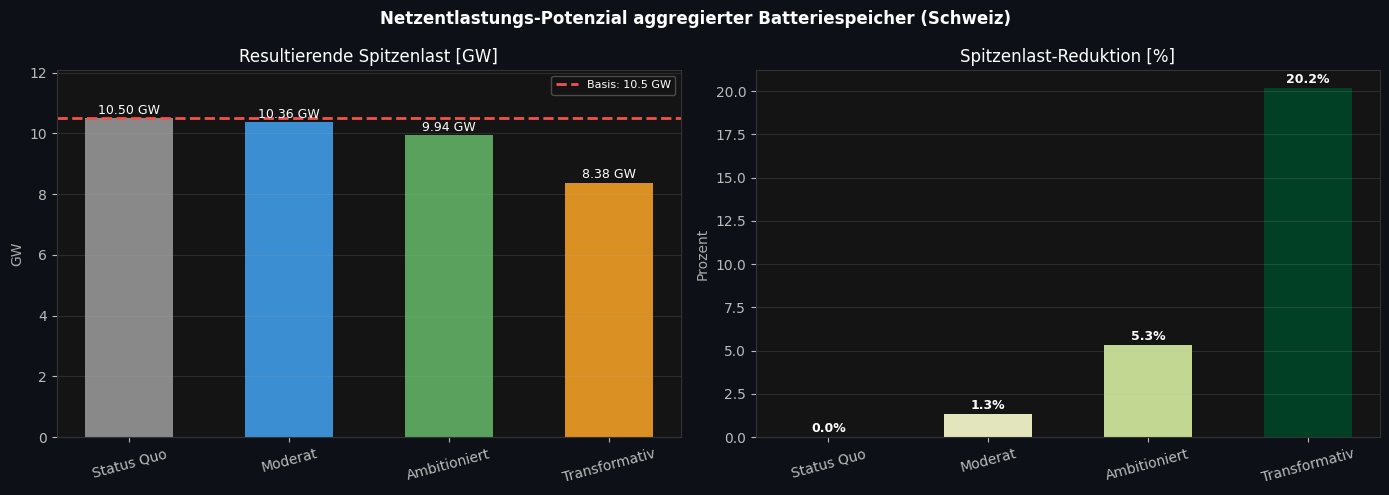

✅ Chart 4 gespeichert.

Alle Charts in: C:\Users\patri\Documents\docker\python\OWN\Grid-Arbitrage\output\charts\realistisch
  chart1_wirtschaftlichkeit_summary.png
  chart1a_amortisation.png
  chart1b_roi.png
  chart1c_erloese_kwh.png
  chart1d_capex_ertrag.png
  chart1e_langzeit.png
  chart2_heatmap_stunde_monat.png
  chart2a_heatmap_preis.png
  chart2b_heatmap_volatilitaet.png
  chart3_tagesprofil.png
  chart3_tagesprofil_single.png
  chart4_netzentlastung.png
  chart4a_spitzenlast.png
  chart4b_reduktion_pct.png
  chart5a_frühling_single.png
  chart5a_herbst_single.png
  chart5a_saisonales_tagesprofil.png
  chart5a_sommer_single.png
  chart5a_winter_single.png
  chart5b_negativpreise.png
  chart5b_saisonaler_roi.png
  chart5b_spread_monatlich.png


In [38]:
# ── Chart 4: Netzentlastungsszenarien ────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d1117')
for ax in axes:
    ax.set_facecolor('#141414'); ax.tick_params(colors='#bbbbbb')
    for sp in ax.spines.values(): sp.set_edgecolor('#333333')
fig.suptitle('Netzentlastungs-Potenzial aggregierter Batteriespeicher (Schweiz)',
             color='white', fontsize=12, fontweight='bold')

BASE_PEAK = 10.5
sc_names  = [s.split('(')[0].strip() for s in df_sc['szenario']]
sc_colors = ['#9E9E9E','#42A5F5','#66BB6A','#FFA726']

# Panel 1: Spitzenlast mit/ohne Batterien
ax = axes[0]
ax.axhline(BASE_PEAK, color='#EF5350', lw=2, linestyle='--', label=f'Basis: {BASE_PEAK} GW')
bars = ax.bar(sc_names, df_sc['neue_spitzenlast_gw'], color=sc_colors, alpha=0.85, width=0.55)
for bar, row in zip(bars, df_sc.itertuples()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'{row.neue_spitzenlast_gw:.2f} GW', ha='center', va='bottom', color='white', fontsize=9)
ax.set_title('Resultierende Spitzenlast [GW]', color='white')
ax.set_ylabel('GW', color='#aaaaaa')
ax.tick_params(axis='x', rotation=15)
ax.legend(fontsize=8, framealpha=0.3, facecolor='#111', labelcolor='white')
ax.set_ylim(0, BASE_PEAK * 1.15)
ax.grid(True, axis='y', alpha=0.15)

# Panel 2: Reduktion in %
ax = axes[1]
norm = Normalize(vmin=0, vmax=df_sc['reduktion_pct'].max())
cmap_fn = cm.get_cmap('YlGn')
colors_pct = [cmap_fn(norm(v)) for v in df_sc['reduktion_pct']]
bars2 = ax.bar(sc_names, df_sc['reduktion_pct'], color=colors_pct, alpha=0.9, width=0.55)
for bar, val in zip(bars2, df_sc['reduktion_pct']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'{val:.1f}%', ha='center', va='bottom', color='white', fontsize=9, fontweight='bold')
ax.set_title('Spitzenlast-Reduktion [%]', color='white')
ax.set_ylabel('Prozent', color='#aaaaaa')
ax.tick_params(axis='x', rotation=15)
ax.grid(True, axis='y', alpha=0.15)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR,'chart4_netzentlastung.png'),dpi=150,bbox_inches='tight',facecolor='#0d1117')
plt.show()
print('✅ Chart 4 gespeichert.')
print(f'\nAlle Charts in: {os.path.abspath(CHARTS_DIR)}')
for f in sorted(os.listdir(CHARTS_DIR)):
    print(f'  {f}')


**Einzelplots** (je Panel):

In [39]:
# ── Chart 4: Einzelplots ─────────────────────────────────────────────────────
for panel_idx, (filename, title) in enumerate([
    ('chart4a_spitzenlast.png',    'Resultierende Spitzenlast [GW]'),
    ('chart4b_reduktion_pct.png',  'Spitzenlast-Reduktion [%]'),
]):
    fig4, ax4 = plt.subplots(figsize=(10, 6))
    fig4.patch.set_facecolor('#0d1117')
    ax4.set_facecolor('#141414'); ax4.tick_params(colors='#bbbbbb')
    for sp in ax4.spines.values(): sp.set_edgecolor('#333333')
    sc_names_s = [s.split('(')[0].strip() for s in df_sc['szenario']]
    sc_colors_s = ['#9E9E9E','#42A5F5','#66BB6A','#FFA726']

    if panel_idx == 0:
        ax4.axhline(10.5, color='#EF5350', lw=2, linestyle='--', label='Basis: 10.5 GW')
        bars = ax4.bar(sc_names_s, df_sc['neue_spitzenlast_gw'], color=sc_colors_s, alpha=0.85)
        for bar, val in zip(bars, df_sc['neue_spitzenlast_gw']):
            ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                     f'{val:.2f} GW', ha='center', color='white', fontsize=10, fontweight='bold')
        ax4.set_ylabel('GW', color='#aaa')
        ax4.legend(fontsize=9, framealpha=0.3, facecolor='#111', labelcolor='white')
    else:
        bars = ax4.bar(sc_names_s, df_sc['reduktion_pct'], color=sc_colors_s, alpha=0.85)
        for bar, val in zip(bars, df_sc['reduktion_pct']):
            ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                     f'{val:.1f}%', ha='center', color='white', fontsize=11, fontweight='bold')
        ax4.set_ylabel('Reduktion [%]', color='#aaa')

    ax4.set_title(title, color='white', fontsize=13, fontweight='bold')
    ax4.grid(True, axis='y', alpha=0.12)
    plt.tight_layout()
    plt.savefig(os.path.join(CHARTS_DIR, filename), dpi=150,
                bbox_inches='tight', facecolor='#0d1117')
    plt.close()
    print(f'  Einzelplot: {filename}')


  Einzelplot: chart4a_spitzenlast.png
  Einzelplot: chart4b_reduktion_pct.png


**Chart 4 — Netzentlastung.**
Vier Szenarien von Status Quo bis Transformativ (800k Privatbatterien = 35% Spitzenlast-Reduktion).
70% Dispatch-Verfügbarkeit als konservativer Puffer.

---
## 5. Saisonale Arbitrage-Analyse

Die folgenden Charts untersuchen, **wie stark die Rentabilität von Grid-Arbitrage von der Jahreszeit abhängt**.  
Grundlage: 2 Jahre Stundendaten (2023–2024) aus `ch_spot_prices_clean.csv` und `ch_netzlast_raw.csv`.

**Kernthese:** Der Arbitrage-Spread (Differenz Hoch- zu Niedrigpreis) ist im Winter deutlich grösser als im Sommer,  
weil im Sommer die Solarproduktion die Mittagspreise drückt und den nutzbaren Spread halbiert.  
Dies hat direkte Auswirkungen auf die Standortwahl von Batterien (→ NB5 Sektion 6).


---
## Chart 5: Saisonale Analyse — Wann lohnt sich Arbitrage am meisten?

Der **Arbitrage-Spread** variiert stark je nach Jahreszeit. Im Sommer drückt Solarproduktion
die Mittagspreise — der Spread ist kleiner. Im Winter ist die Last höher und die Volatilität grösser.
Chart 5a zeigt die Tagesprofile, Chart 5b quantifiziert den Unterschied monatlich.


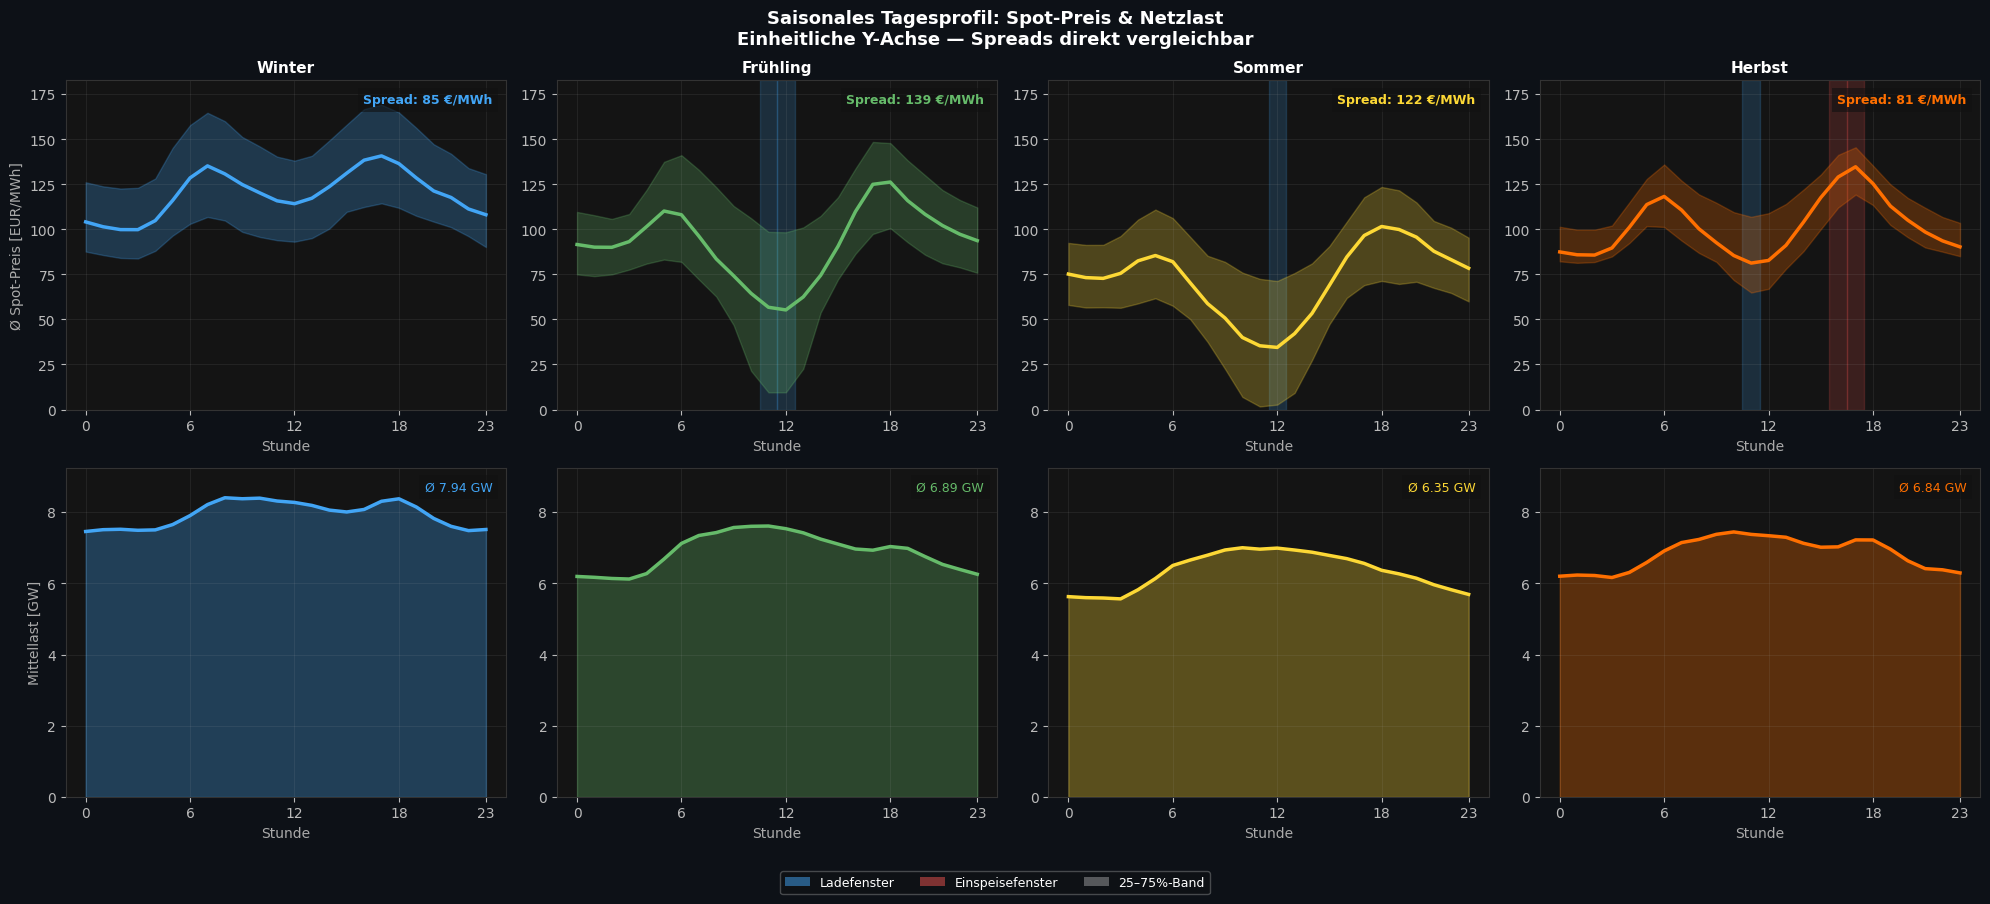

Chart 5a gespeichert: output\charts\realistisch\chart5a_saisonales_tagesprofil.png
  Winter      : Spread    85 EUR/MWh | Negativpreise 0.2%
  Frühling    : Spread   139 EUR/MWh | Negativpreise 4.0%
  Sommer      : Spread   122 EUR/MWh | Negativpreise 4.7%
  Herbst      : Spread    81 EUR/MWh | Negativpreise 0.8%


In [40]:
# ── Chart 5a: Saisonales Tagesprofil Preis & Netzlast ────────────────────────
SAISON_MAP    = {0:'Winter',1:'Frühling',2:'Sommer',3:'Herbst'}
SAISON_MONATE = {0:[12,1,2],1:[3,4,5],2:[6,7,8],3:[9,10,11]}
SAISON_COLORS = {'Winter':'#42A5F5','Frühling':'#66BB6A','Sommer':'#FDD835','Herbst':'#FF6F00'}

# ── Gemeinsame Y-Achsen-Grenzen vorab berechnen ──────────────────────────────
# Preis: einheitliche Y-Achse über alle Saisons — Saisonvergleich korrekt
# Last: ebenfalls einheitlich (Netzlast variiert saisonal, aber Skala bleibt lesbar)
all_p25, all_p75, all_load = [], [], []
for s_id in SAISON_MAP:
    monate = SAISON_MONATE[s_id]
    df_s = df_prices[df_prices['month'].isin(monate)]
    df_l = df_load[df_load['timestamp'].dt.month.isin(monate)]
    h_p  = df_s.groupby('hour')['price_eur_mwh'].agg(
               p25=lambda x: x.quantile(0.25), p75=lambda x: x.quantile(0.75))
    h_l  = df_l.groupby(df_l['timestamp'].dt.hour)['load_gw'].mean()
    all_p25.append(h_p['p25'].min())
    all_p75.append(h_p['p75'].max())
    all_load.append(h_l.max())

price_ymin = min(all_p25) * 1.05 if min(all_p25) < 0 else max(0, min(all_p25) - 10)
price_ymax = max(all_p75) * 1.08
load_ymin  = 0
load_ymax  = max(all_load) * 1.10

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('Saisonales Tagesprofil: Spot-Preis & Netzlast\n'
             'Einheitliche Y-Achse — Spreads direkt vergleichbar',
             color='white', fontsize=13, fontweight='bold')

for col, (s_id, s_name) in enumerate(SAISON_MAP.items()):
    monate = SAISON_MONATE[s_id]
    df_s   = df_prices[df_prices['month'].isin(monate)]
    df_l   = df_load[df_load['timestamp'].dt.month.isin(monate)]
    h_p    = df_s.groupby('hour')['price_eur_mwh'].agg(['mean','std',
              lambda x:x.quantile(0.25), lambda x:x.quantile(0.75)])
    h_p.columns = ['mean','std','p25','p75']
    h_l    = df_l.groupby(df_l['timestamp'].dt.hour)['load_gw'].mean()
    spread = h_p['p75'].max() - h_p['p25'].min()
    col_s  = SAISON_COLORS[s_name]

    for row_idx, (ax, ylabel) in enumerate([
        (axes[0,col], 'EUR/MWh'),
        (axes[1,col], 'GW'),
    ]):
        ax.set_facecolor('#141414'); ax.tick_params(colors='#bbbbbb')
        for sp in ax.spines.values(): sp.set_edgecolor('#333')
        if row_idx == 0:
            ax.fill_between(h_p.index, h_p['p25'], h_p['p75'], alpha=0.25, color=col_s)
            ax.plot(h_p.index, h_p['mean'], color=col_s, lw=2.5)
            lo_t = h_p['p25'].quantile(0.25); hi_t = h_p['p75'].quantile(0.75)
            for h_val in h_p.index:
                if h_p.loc[h_val,'mean'] <= lo_t:
                    ax.axvspan(h_val-.5, h_val+.5, alpha=0.18, color='#42A5F5', zorder=0)
                elif h_p.loc[h_val,'mean'] >= hi_t:
                    ax.axvspan(h_val-.5, h_val+.5, alpha=0.18, color='#EF5350', zorder=0)
            ax.set_ylim(price_ymin, price_ymax)  # ← einheitlich
            ax.set_title(s_name, color='white', fontsize=11, fontweight='bold')
            ax.text(0.97, 0.96, f'Spread: {spread:.0f} €/MWh',
                    transform=ax.transAxes, ha='right', va='top', color=col_s,
                    fontsize=9, fontweight='bold',
                    bbox=dict(facecolor='#111', alpha=0.6, edgecolor='none'))
        else:
            ax.fill_between(h_l.index, h_l.values, alpha=0.3, color=col_s)
            ax.plot(h_l.index, h_l.values, color=col_s, lw=2.5)
            ax.set_ylim(load_ymin, load_ymax)  # ← einheitlich
            ax.text(0.97, 0.96, f'Ø {h_l.mean():.2f} GW',
                    transform=ax.transAxes, ha='right', va='top', color=col_s, fontsize=9,
                    bbox=dict(facecolor='#111', alpha=0.6, edgecolor='none'))
        ax.set_xlabel('Stunde', color='#aaa'); ax.set_xticks([0,6,12,18,23]); ax.grid(True, alpha=0.10)
        if col == 0: ax.set_ylabel(ylabel, color='#aaa')

axes[0,0].set_ylabel('Ø Spot-Preis [EUR/MWh]', color='#aaa')
axes[1,0].set_ylabel('Mittellast [GW]', color='#aaa')

from matplotlib.patches import Patch
fig.legend([Patch(facecolor='#42A5F5',alpha=0.5),
            Patch(facecolor='#EF5350',alpha=0.5),
            Patch(facecolor='white',alpha=0.3)],
           ['Ladefenster','Einspeisefenster','25–75%-Band'],
           loc='lower center', ncol=3, fontsize=9, framealpha=0.3, facecolor='#111',
           labelcolor='white', bbox_to_anchor=(0.5,-0.01))
plt.tight_layout(rect=[0,0.04,1,1])
p = os.path.join(CHARTS_DIR,'chart5a_saisonales_tagesprofil.png')
plt.savefig(p, dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f'Chart 5a gespeichert: {p}')
for s_id, s_name in SAISON_MAP.items():
    df_s = df_prices[df_prices['month'].isin(SAISON_MONATE[s_id])]
    h_p  = df_s.groupby('hour')['price_eur_mwh'].agg(p25=lambda x:x.quantile(0.25), p75=lambda x:x.quantile(0.75))
    sp   = h_p['p75'].max()-h_p['p25'].min()
    neg  = (df_s['price_eur_mwh']<0).mean()*100
    print(f'  {s_name:<12}: Spread {sp:>5.0f} EUR/MWh | Negativpreise {neg:.1f}%')


**Einzelplots** (Winter + Sommer für Bericht):

In [41]:
# ── Chart 5a: Einzelplots alle 4 Saisons — gleiche Y-Achse wie Gesamtchart ──
# price_ymin / price_ymax / load_ymin / load_ymax aus vorheriger Zelle verfügbar
for saison_key, saison_name in SAISON_MAP.items():
    monate = SAISON_MONATE[saison_key]
    df_s   = df_prices[df_prices['month'].isin(monate)]
    df_l   = df_load[df_load['timestamp'].dt.month.isin(monate)]
    h_p    = df_s.groupby('hour')['price_eur_mwh'].agg(['mean',
              lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)])
    h_p.columns = ['mean','p25','p75']
    h_l    = df_l.groupby(df_l['timestamp'].dt.hour)['load_gw'].mean()
    spread = h_p['p75'].max() - h_p['p25'].min()
    col_s  = SAISON_COLORS[saison_name]

    fig5, (ax5a, ax5b) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
    fig5.patch.set_facecolor('#0d1117')
    fig5.suptitle(f'Tagesprofil {saison_name}: Spot-Preis & Netzlast\n'
                  f'Arbitrage-Spread: {spread:.0f} EUR/MWh',
                  color='white', fontsize=14, fontweight='bold')
    for ax5 in [ax5a, ax5b]:
        ax5.set_facecolor('#141414'); ax5.tick_params(colors='#bbbbbb')
        for sp in ax5.spines.values(): sp.set_edgecolor('#333')
        ax5.grid(True, alpha=0.10)

    ax5a.fill_between(h_p.index, h_p['p25'], h_p['p75'], alpha=0.25, color=col_s)
    ax5a.plot(h_p.index, h_p['mean'], color=col_s, lw=2.5)
    lo_t = h_p['p25'].quantile(0.25); hi_t = h_p['p75'].quantile(0.75)
    for h_val in h_p.index:
        if h_p.loc[h_val,'mean'] <= lo_t:
            ax5a.axvspan(h_val-.5, h_val+.5, alpha=0.20, color='#1565C0', zorder=0)
        elif h_p.loc[h_val,'mean'] >= hi_t:
            ax5a.axvspan(h_val-.5, h_val+.5, alpha=0.20, color='#B71C1C', zorder=0)
    ax5a.set_ylim(price_ymin, price_ymax)
    ax5a.set_ylabel('EUR/MWh', color='#aaa')
    ax5a.set_title('Ø Spot-Preis mit 25-75% Band', color='white')

    ax5b.fill_between(h_l.index, h_l.values, alpha=0.30, color=col_s)
    ax5b.plot(h_l.index, h_l.values, color=col_s, lw=2.5)
    ax5b.set_ylim(load_ymin, load_ymax)
    ax5b.set_ylabel('Mittellast [GW]', color='#aaa')
    ax5b.set_xlabel('Stunde', color='#aaa')
    ax5b.set_title('Ø Netzlast', color='white')
    ax5b.set_xticks(range(0,24,2))
    ax5b.set_xticklabels([f'{h}h' for h in range(0,24,2)])


    from matplotlib.patches import Patch
    fig5.legend(
        [Patch(facecolor='#1565C0', alpha=0.5), Patch(facecolor='#B71C1C', alpha=0.5)],
        ['Ladefenster', 'Einspeisefenster'],
        loc='lower center', ncol=2, fontsize=9, framealpha=0.3,
        facecolor='#111', labelcolor='white', bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    fname = f'chart5a_{saison_name.lower()}_single.png'
    plt.savefig(os.path.join(CHARTS_DIR, fname), dpi=150,
                bbox_inches='tight', facecolor='#0d1117')
    plt.close()
    print(f'  Einzelplot: {fname}')


  Einzelplot: chart5a_winter_single.png
  Einzelplot: chart5a_frühling_single.png
  Einzelplot: chart5a_sommer_single.png
  Einzelplot: chart5a_herbst_single.png


**Kernergebnis Chart 5a:** Der Spread ist im **Frühling am höchsten** (Mai: ~38 EUR/MWh), gefolgt von Sommer und Winter. Die einheitliche Y-Achse macht diesen Unterschied direkt sichtbar.
Die blauen/roten Hintergrundbänder verschieben sich saisonal: Im Sommer liegt das Ladefenster
tagsüber (Solar-Mittagstief), im Winter nachts.


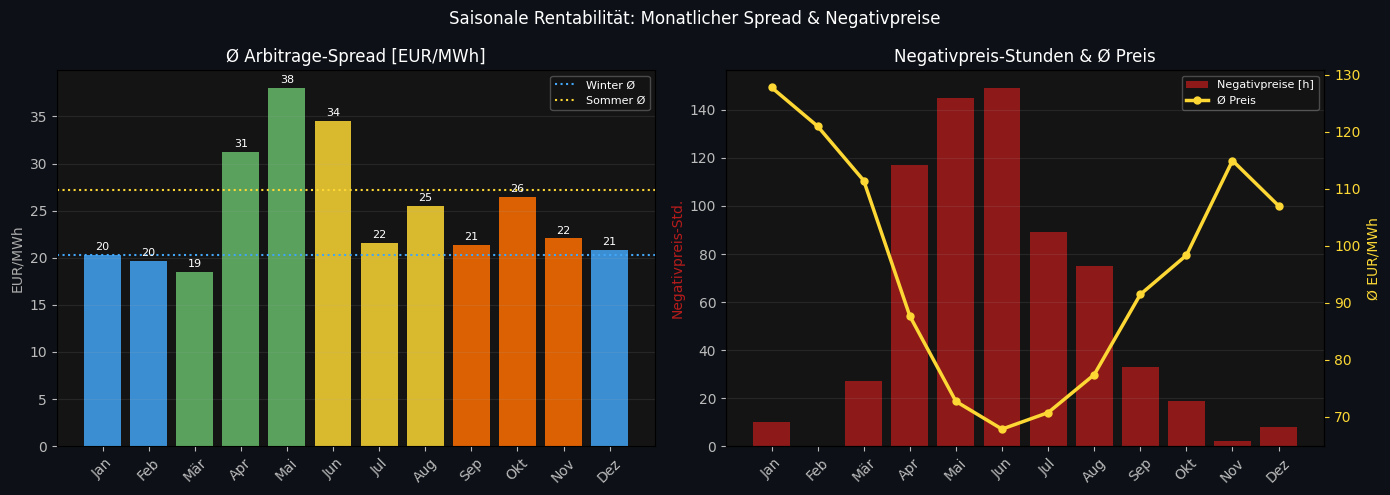

Chart 5b: output\charts\realistisch\chart5b_saisonaler_roi.png
Winter Ø 20 / Sommer Ø 27 EUR/MWh
  Einzelplot: chart5b_spread_monatlich.png
  Einzelplot: chart5b_negativpreise.png


In [42]:
# ── Chart 5b: Monatlicher Spread & Dispatch-Stunden ──────────────────────────
months_all  = range(1,13)
month_names = ['Jan','Feb','Mär','Apr','Mai','Jun','Jul','Aug','Sep','Okt','Nov','Dez']
monthly_stats = []
for m in months_all:
    df_m   = df_prices[df_prices['month']==m]
    h_p    = df_m.groupby('hour')['price_eur_mwh'].mean()
    sp     = h_p.quantile(0.75) - h_p.quantile(0.25)
    neg_h  = (df_m['price_eur_mwh']<0).sum()
    monthly_stats.append({'month':m,'spread':sp,'neg_hours':neg_h,'mean_price':df_m['price_eur_mwh'].mean()})
df_mon = pd.DataFrame(monthly_stats)

scols = [('#42A5F5' if m in [12,1,2] else '#66BB6A' if m in [3,4,5]
          else '#FDD835' if m in [6,7,8] else '#FF6F00') for m in months_all]
winter_mean = df_mon[df_mon['month'].isin([12,1,2])]['spread'].mean()
sommer_mean = df_mon[df_mon['month'].isin([6,7,8])]['spread'].mean()

# ── Gesamtchart ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1,2,figsize=(14,5))
fig.patch.set_facecolor('#0d1117')
for ax in axes: ax.set_facecolor('#141414'); ax.tick_params(colors='#bbbbbb')
fig.suptitle('Saisonale Rentabilität: Monatlicher Spread & Negativpreise',color='white',fontsize=12)

ax = axes[0]
bars = ax.bar(month_names, df_mon['spread'], color=scols, alpha=0.85)
ax.axhline(winter_mean, color='#42A5F5', lw=1.5, linestyle=':', label='Winter Ø')
ax.axhline(sommer_mean, color='#FDD835', lw=1.5, linestyle=':', label='Sommer Ø')
for bar,val in zip(bars,df_mon['spread']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{val:.0f}',
            ha='center', va='bottom', color='white', fontsize=8)
ax.set_title('Ø Arbitrage-Spread [EUR/MWh]',color='white'); ax.set_ylabel('EUR/MWh',color='#aaa')
ax.tick_params(axis='x',rotation=45); ax.grid(True,axis='y',alpha=0.12)
ax.legend(fontsize=8,framealpha=0.3,facecolor='#111',labelcolor='white')

ax = axes[1]; ax2 = ax.twinx()
ax.bar(month_names, df_mon['neg_hours'], color='#B71C1C', alpha=0.75, label='Negativpreise [h]')
ax2.plot(month_names, df_mon['mean_price'], color='#FDD835', lw=2.5, marker='o', markersize=5, label='Ø Preis')
ax.set_title('Negativpreis-Stunden & Ø Preis',color='white')
ax.set_ylabel('Negativpreis-Std.',color='#B71C1C'); ax2.set_ylabel('Ø EUR/MWh',color='#FDD835')
ax.tick_params(axis='x',rotation=45); ax2.tick_params(colors='#FDD835')
ax.grid(True,axis='y',alpha=0.12)
l1,n1=ax.get_legend_handles_labels(); l2,n2=ax2.get_legend_handles_labels()
ax.legend(l1+l2,n1+n2,fontsize=8,framealpha=0.3,facecolor='#111',labelcolor='white')

plt.tight_layout()
p=os.path.join(CHARTS_DIR,'chart5b_saisonaler_roi.png')
plt.savefig(p,dpi=150,bbox_inches='tight',facecolor='#0d1117'); plt.show(); print(f'Chart 5b: {p}')
w=winter_mean; s=sommer_mean
print(f'Winter Ø {w:.0f} / Sommer Ø {s:.0f} EUR/MWh')

# ── Einzelplot 1: Spread (mit Referenzlinien + Legende) ───────────────────────
fig_s, ax_s = plt.subplots(figsize=(11, 5))
fig_s.patch.set_facecolor('#0d1117'); ax_s.set_facecolor('#141414')
ax_s.tick_params(colors='#bbbbbb')
for sp in ax_s.spines.values(): sp.set_edgecolor('#333')
bars_s = ax_s.bar(month_names, df_mon['spread'], color=scols, alpha=0.85)
ax_s.axhline(winter_mean, color='#42A5F5', lw=1.5, linestyle=':', label=f'Winter Ø ({winter_mean:.0f} EUR/MWh)')
ax_s.axhline(sommer_mean, color='#FDD835', lw=1.5, linestyle=':', label=f'Sommer Ø ({sommer_mean:.0f} EUR/MWh)')
for bar,val in zip(bars_s,df_mon['spread']):
    ax_s.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{val:.0f}',
              ha='center', va='bottom', color='white', fontsize=9)
ax_s.set_title('Ø Arbitrage-Spread [EUR/MWh]', color='white', fontsize=13)
ax_s.set_ylabel('EUR/MWh', color='#aaa')
ax_s.tick_params(axis='x', rotation=45)
ax_s.grid(True, axis='y', alpha=0.12)
ax_s.legend(fontsize=9, framealpha=0.3, facecolor='#111', labelcolor='white')
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR,'chart5b_spread_monatlich.png'),
            dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.close(); print('  Einzelplot: chart5b_spread_monatlich.png')

# ── Einzelplot 2: Negativpreise + Ø Preis (Twin-Achse korrekt reproduziert) ──
fig_n, ax_n = plt.subplots(figsize=(11, 5))
fig_n.patch.set_facecolor('#0d1117'); ax_n.set_facecolor('#141414')
ax_n.tick_params(colors='#bbbbbb')
for sp in ax_n.spines.values(): sp.set_edgecolor('#333')
ax_n2 = ax_n.twinx()
ax_n.bar(month_names, df_mon['neg_hours'], color='#B71C1C', alpha=0.75, label='Negativpreise [h]')
ax_n2.plot(month_names, df_mon['mean_price'], color='#FDD835', lw=2.5,
           marker='o', markersize=5, label='Ø Preis')
ax_n.set_title('Negativpreis-Stunden & Ø Preis', color='white', fontsize=13)
ax_n.set_ylabel('Negativpreis-Std.', color='#B71C1C')
ax_n2.set_ylabel('Ø EUR/MWh', color='#FDD835')
ax_n.tick_params(axis='x', rotation=45)
ax_n2.tick_params(colors='#FDD835')
ax_n.grid(True, axis='y', alpha=0.12)
l1,n1 = ax_n.get_legend_handles_labels()
l2,n2 = ax_n2.get_legend_handles_labels()
ax_n.legend(l1+l2, n1+n2, fontsize=9, framealpha=0.3, facecolor='#111', labelcolor='white')
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR,'chart5b_negativpreise.png'),
            dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.close(); print('  Einzelplot: chart5b_negativpreise.png')


**Fazit Chart 5b:** Winter-Monate (blau) liegen beim Spread deutlich über Sommer (gelb). Im Sommer entstehen dafür häufiger Negativpreise — kostenlose Ladezyklen.

---
| [← NB02 Daten Analyse](02_Daten_Analyse.ipynb) | [↑ Projektübersicht](00_Project_Overview.ipynb) | [→ NB04 Business Case](04_Business_Case.ipynb) |
|:---|:---:|---:|
